In [16]:
import pandas as pd 
df = pd.read_csv(r'C:\Users\narro\OneDrive - Fundacion Universidad de las Americas Puebla\semestre 9\redes\redes_local\datos\processed\df.csv')

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import numpy as np


In [18]:
import numpy as np

# Columnas que NO son features
meta_cols = ["filename", "painter", "genre", "label"]

# Todas las columnas que consideramos features
feature_cols = [c for c in df.columns if c not in meta_cols]

# Asegurarnos de que son numéricas
X = df[feature_cols].to_numpy(dtype=np.float32)   # (n_samples, n_features)
y = df["label"].to_numpy(dtype=np.int64)          # (n_samples,)

print("Shapes X, y:", X.shape, y.shape)
print("Conteo por clase en y:", np.bincount(y))
print("Orden de features:", feature_cols)


Shapes X, y: (200, 53) (200,)
Conteo por clase en y: [50 30 15 30 75]
Orden de features: ['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B', 'min_R', 'min_G', 'min_B', 'max_R', 'max_G', 'max_B', 'mean_S', 'std_S', 'mean_V', 'std_V', 'rms', 'sobel_mean', 'sobel_std', 'sobel_pct_strong', 'laplacian_mean_abs', 'laplacian_std_abs', 'gabor_mean_abs_0', 'gabor_std_abs_0', 'gabor_mean_abs_45', 'gabor_std_abs_45', 'gabor_mean_abs_90', 'gabor_std_abs_90', 'gabor_mean_abs_135', 'gabor_std_abs_135', 'mean_block_0_0', 'pct_bright_block_0_0', 'mean_block_0_1', 'pct_bright_block_0_1', 'mean_block_0_2', 'pct_bright_block_0_2', 'mean_block_1_0', 'pct_bright_block_1_0', 'mean_block_1_1', 'pct_bright_block_1_1', 'mean_block_1_2', 'pct_bright_block_1_2', 'mean_block_2_0', 'pct_bright_block_2_0', 'mean_block_2_1', 'pct_bright_block_2_1', 'mean_block_2_2', 'pct_bright_block_2_2', 'H_shannon', 'center_mean_ratio', 'center_bright_ratio', 'lum_centroid_x', 'lum_centroid_y']


In [19]:
smote = SMOTE(random_state=42, k_neighbors=3)

pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", smote),
    ("clf", MLPClassifier(
        max_iter=1000,
        random_state=42
    ))
])


In [20]:
param_grid = {
    "clf__hidden_layer_sizes": [
        (32,),
        (48,),
        (32, 16),
    ],
    "clf__activation": ["relu", "tanh", "logistic"],
    "clf__alpha": [1e-4, 1e-3],
}


In [21]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



In [22]:
grid = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor F1 macro (CV):", grid.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline base: scaler + SMOTE + MLP
smote = SMOTE(random_state=42, k_neighbors=3)

pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", smote),
    ("clf", MLPClassifier(max_iter=1000, random_state=42))
])

# Hiperparámetros a probar
param_grid = {
    "clf__hidden_layer_sizes": [
        (32,),
        (48,),
        (32, 16),
    ],
    "clf__activation": ["relu", "tanh", "logistic"],
    "clf__alpha": [1e-4, 1e-3],
}

# 👇 AQUÍ defines cv
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid search
grid = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__activation': ['relu', 'tanh', ...], 'clf__alpha': [0.0001, 0.001], 'clf__hidden_layer_sizes': [(32,), (48,), ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [ ]:
best_mlp = grid.best_estimator_
best_mlp.fit(X, y)


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,3
,hidden_layer_sizes,"(32,)"


Accuracy: 1.0
R²: 1.0

Matriz de confusión:
 [[50  0  0  0  0]
 [ 0 30  0  0  0]
 [ 0  0 15  0  0]
 [ 0  0  0 30  0]
 [ 0  0  0  0 75]]


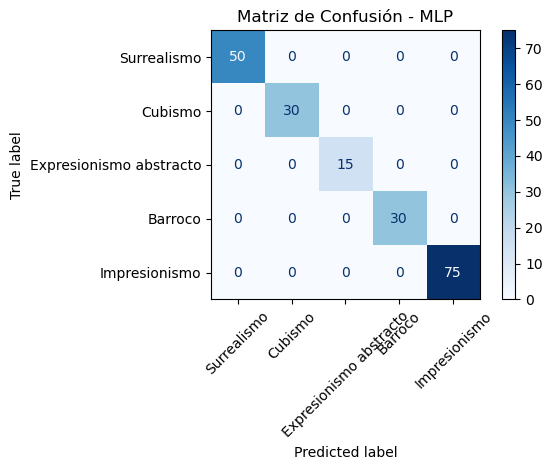


Reporte de clasificación:
                         precision    recall  f1-score   support

            Surrealismo      1.000     1.000     1.000        50
                Cubismo      1.000     1.000     1.000        30
Expresionismo abstracto      1.000     1.000     1.000        15
                Barroco      1.000     1.000     1.000        30
          Impresionismo      1.000     1.000     1.000        75

               accuracy                          1.000       200
              macro avg      1.000     1.000     1.000       200
           weighted avg      1.000     1.000     1.000       200



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

# Predicciones en tu set completo de 200 imágenes
y_pred = best_mlp.predict(X)

# Accuracy
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

# R² (no es tan común para clasificación, pero sí se puede pedir)
r2 = r2_score(y, y_pred)
print("R²:", r2)

# Matriz de Confusión
cm = confusion_matrix(y, y_pred)
print("\nMatriz de confusión:\n", cm)

# Visualizar matriz
class_names = ["Surrealismo", "Cubismo", "Expresionismo abstracto", "Barroco", "Impresionismo"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - MLP")
plt.tight_layout()
plt.show()

# Reporte detallado
print("\nReporte de clasificación:")
print(classification_report(y, y_pred, digits=3, target_names=class_names))


In [ ]:
from sklearn.model_selection import train_test_split

# X, y ya definidos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% para test (40 imágenes si tienes 200)
    stratify=y,
    random_state=123
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(160, 53) (160,)
(40, 53) (40,)


In [ ]:
print(grid.best_params_)


{'clf__activation': 'tanh', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (32,)}


In [ ]:
{
    'clf__hidden_layer_sizes': (32,),
    'clf__activation': 'relu',
    'clf__alpha': 0.0001
}


{'clf__hidden_layer_sizes': (32,),
 'clf__activation': 'relu',
 'clf__alpha': 0.0001}

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Mismo SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)

pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", smote),
    ("clf", MLPClassifier(
        max_iter=1000,
        random_state=42
    ))
])

# Aplicar los mejores hiperparámetros encontrados en el grid
pipe_final.set_params(**grid.best_params_)

# Entrenar SOLO con train
pipe_final.fit(X_train, y_train)


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,3
,hidden_layer_sizes,"(32,)"


Accuracy (test): 0.725
F1 macro (test): 0.652063492063492

Matriz de confusión (test):
 [[ 8  0  2  0  0]
 [ 2  1  1  1  1]
 [ 0  0  3  0  0]
 [ 0  1  0  5  0]
 [ 0  1  0  2 12]]


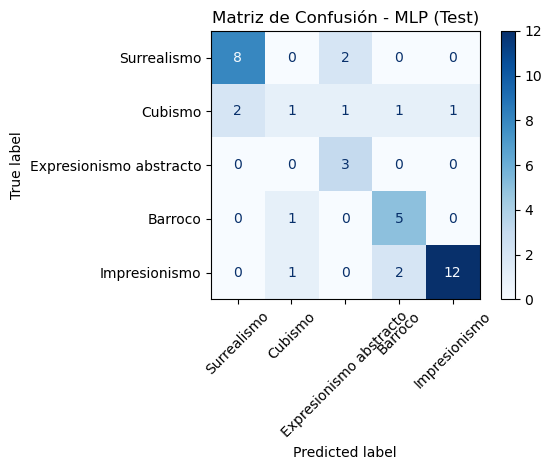


Reporte de clasificación (test):
                         precision    recall  f1-score   support

            Surrealismo      0.800     0.800     0.800        10
                Cubismo      0.333     0.167     0.222         6
Expresionismo abstracto      0.500     1.000     0.667         3
                Barroco      0.625     0.833     0.714         6
          Impresionismo      0.923     0.800     0.857        15

               accuracy                          0.725        40
              macro avg      0.636     0.720     0.652        40
           weighted avg      0.727     0.725     0.712        40



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

# Predicciones en el set de TEST (nunca visto por este modelo)
y_pred_test = pipe_final.predict(X_test)

# Accuracy y F1
acc_test = accuracy_score(y_test, y_pred_test)
f1_macro_test = f1_score(y_test, y_pred_test, average="macro")

print("Accuracy (test):", acc_test)
print("F1 macro (test):", f1_macro_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
class_names = ["Surrealismo", "Cubismo", "Expresionismo abstracto", "Barroco", "Impresionismo"]

print("\nMatriz de confusión (test):\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - MLP (Test)")
plt.tight_layout()
plt.show()

# Reporte detallado
print("\nReporte de clasificación (test):")
print(classification_report(y_test, y_pred_test, digits=3, target_names=class_names))


In [27]:
pipe_final.fit(X_train, y_train)


,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,3
,hidden_layer_sizes,"(32,)"


Iteraciones realizadas: 455


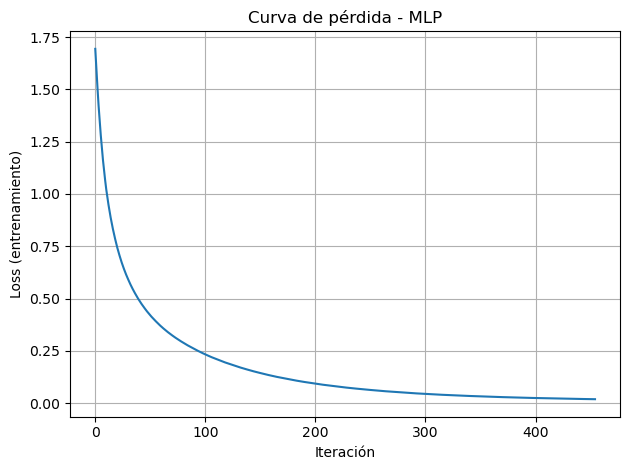

In [28]:
import matplotlib.pyplot as plt

clf = pipe_final.named_steps["clf"]   # el MLP dentro del pipeline

print("Iteraciones realizadas:", clf.n_iter_)

plt.plot(clf.loss_curve_)
plt.xlabel("Iteración")
plt.ylabel("Loss (entrenamiento)")
plt.title("Curva de pérdida - MLP")
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
pipe_final.fit(X_test, y_test)

ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 4, n_samples_fit = 3, n_samples = 3